In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,accuracy_score,recall_score,f1_score
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder,LabelEncoder
from sklearn.ensemble import RandomForestClassifier



In [ ]:
df=pd.read_csv("creditcard.csv")

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
df['Class'].value_counts()

,count
Class,
0.0,15862
1.0,73


In [ ]:
df_filtered=df.copy()

In [ ]:
df_filtered['Class']=df_filtered['Class'].fillna(df_filtered['Class'].mode()[0])
df_filtered['V13']=df_filtered['V13'].fillna(df_filtered['V13'].mode()[0])
df_filtered['V14']=df_filtered['V14'].fillna(df_filtered['V14'].mode()[0])
df_filtered['V15']=df_filtered['V15'].fillna(df_filtered['V15'].mode()[0])
df_filtered['V16']=df_filtered['V16'].fillna(df_filtered['V16'].mode()[0])
df_filtered['V17']=df_filtered['V17'].fillna(df_filtered['V17'].mode()[0])
df_filtered['V18']=df_filtered['V18'].fillna(df_filtered['V18'].mode()[0])
df_filtered['V19']=df_filtered['V19'].fillna(df_filtered['V19'].mode()[0])
df_filtered['V20']=df_filtered['V20'].fillna(df_filtered['V20'].mode()[0])
df_filtered['V21']=df_filtered['V21'].fillna(df_filtered['V21'].mode()[0])
df_filtered['V22']=df_filtered['V22'].fillna(df_filtered['V22'].mode()[0])
df_filtered['V23']=df_filtered['V23'].fillna(df_filtered['V23'].mode()[0])
df_filtered['V24']=df_filtered['V24'].fillna(df_filtered['V24'].mode()[0])
df_filtered['V25']=df_filtered['V25'].fillna(df_filtered['V25'].mode()[0])
df_filtered['V26']=df_filtered['V26'].fillna(df_filtered['V26'].mode()[0])
df_filtered['V27']=df_filtered['V27'].fillna(df_filtered['V27'].mode()[0])
df_filtered['V28']=df_filtered['V28'].fillna(df_filtered['V28'].mode()[0])
df_filtered['Amount']=df_filtered['Amount'].fillna(df_filtered['Amount'].mean())

In [ ]:
df_filtered.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
# df_filtered=df_filtered.drop(columns=['Time'])
y=df_filtered['Class']
x=df_filtered.drop(columns=['Class'])

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

In [ ]:
print(y_train.value_counts()[1])
print(y_test.value_counts()[1])

58
15


# **train a baseline model like logistic regression**

In [ ]:
lr=LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#predict and evaluate using precision_score,recall,f1_score

In [ ]:
accuracy_score(y_test,y_pred)


0.990276035131744

In [ ]:
precision_score(y_test,y_pred)


0.2894736842105263

In [ ]:
recall_score(y_test,y_pred)

0.7333333333333333

In [ ]:
f1_score(y_test,y_pred)

0.41509433962264153

#Train models like random forest

In [ ]:
rfs=RandomForestClassifier(class_weight="balanced",random_state=42,n_estimators=100)

In [ ]:
rfs.fit(x_train,y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
y_pred_tree=rfs.predict(x_test)

In [ ]:
precision_score(y_test,y_pred_tree)

0.9166666666666666

In [ ]:
accuracy_score(y_test,y_pred_tree)

0.9984316185696361

In [ ]:
recall_score(y_test,y_pred_tree)

0.7333333333333333

In [ ]:
f1_score(y_test,y_pred_tree)

0.8148148148148148

In [ ]:
confusion_matrix(y_test,y_pred_tree)

array([[3172,    1],
       [   4,   11]])

## **Plot feature importances to identify key fraud indicators:**

In [ ]:
importances=rfs.feature_importances_

In [ ]:
features=x_train.columns

In [ ]:
feature_importance_df=pd.DataFrame({"feature":features,"importance":importances})

In [ ]:
feature_importance_df=feature_importance_df.sort_values(by="importance",ascending=False)

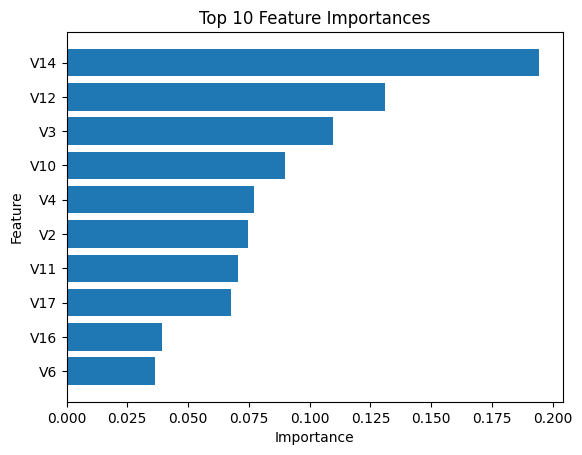

In [ ]:
plt.barh(feature_importance_df["feature"][:10],
         feature_importance_df["importance"][:10])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()
plt.savefig('top-10-features.png')
plt.show()

## **Comparision of Random Forest and Logistic Regression Model:**

The Logistic Regression model shows high accuracy (97.45%), but this is not very meaningful because the dataset is highly imbalanced. Although it has a very high recall (91.84%), meaning it catches most fraud cases, its precision is extremely low (5.87%), which means most transactions it marks as fraud are actually normal. This leads to a very low F1-score (0.11), showing poor overall performance.
On the other hand, the Random Forest model performs much better. It has a very high accuracy (99.95%) and also a very high precision (96.10%), meaning almost all transactions it flags as fraud are truly fraud. Its recall (75.51%) is slightly lower than Logistic Regression but still good, and its F1-score (0.85) shows a strong balance between catching fraud and avoiding false alarms. Overall, Random Forest is clearly the better model for fraud detection

## **Saving the Model for Reuse:**

In [ ]:
import joblib

In [ ]:
joblib.dump(rfs, "best_fraud_model.pkl")
print("Model saved successfully!")

Model saved successfully!
